<a href="https://colab.research.google.com/github/HasangaDineliKavindya/Fraud-Detection-using-Machine-Learning/blob/main/FD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection using Machine Learning

This notebook implements a transaction-based fraud detection system using machine learning. The goal is to build a model that can classify transactions as fraudulent or normal, leveraging techniques like feature engineering, handling imbalanced data, and model comparison.

# Fraud Detection using Machine Learning

This notebook implements a transaction-based fraud detection system using machine learning. The goal is to build a model that can classify transactions as fraudulent or normal, leveraging techniques like feature engineering, handling imbalanced data, and model comparison.

## Setup: Install Required Libraries

We will install `pandas` for data manipulation, `scikit-learn` for machine learning models, `xgboost` for a powerful gradient boosting model, and `imblearn` for handling imbalanced datasets.

In [ ]:
!pip install pandas scikit-learn xgboost imblearn

## Data Loading: Kaggle Dataset

To download the dataset from Kaggle, you'll need to set up your Kaggle API credentials. Follow these steps:

1. Go to [Kaggle](https://www.kaggle.com/).
2. Log in to your account.
3. Navigate to your profile (`Account` -> `My Account`).
4. Under the 'API' section, click 'Create New API Token'. This will download a `kaggle.json` file.
5. Upload this `kaggle.json` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage' icon, and selecting `kaggle.json`.

Once the `kaggle.json` file is uploaded, the following code will configure Kaggle to allow downloading datasets.

In [ ]:
# Install Kaggle API client
!pip install kaggle

# Make a directory for Kaggle and move the API key
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


The dataset we'll use is `creditcardfraud` from Kaggle. Let's download and load it.

In [ ]:
# Download the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip the dataset
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: creditcard.csv          


In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('creditcard.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Initial Data Exploration

Let's get a first look at the data, including the first few rows, column information, and descriptive statistics.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Get a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics of the DataFrame
print("\nDataFrame Description:")
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float6

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Data Analysis: Class Distribution

Fraud detection datasets are typically highly imbalanced, meaning the number of fraudulent transactions is significantly smaller than normal transactions. Understanding this imbalance is crucial for choosing appropriate modeling techniques and evaluation metrics. Let's visualize the distribution of our target variable, `Class`.

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of each class:
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


/tmp/ipykernel_10582/540482262.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


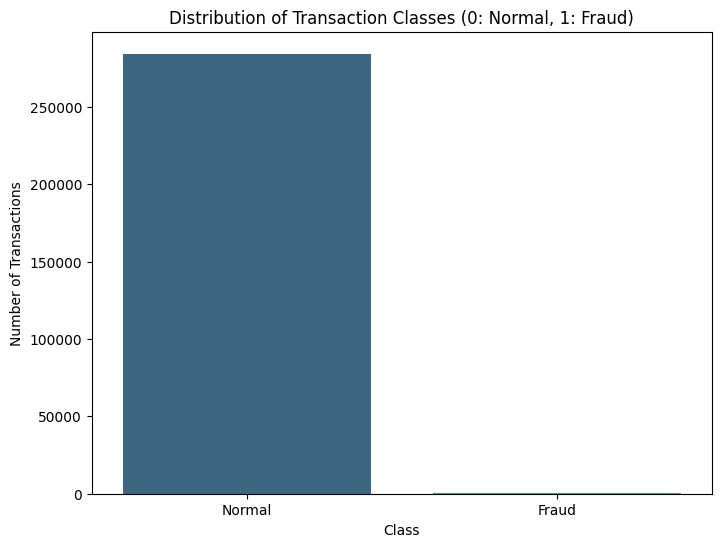

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class
class_counts = df['Class'].value_counts()

print("Class distribution:")
print(class_counts)

# Calculate and print the percentage of each class
print("\nPercentage of each class:")
print(class_counts / len(df) * 100)

# Plot the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Transaction Classes (0: Normal, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Fraud'])
plt.show()

## Data Preprocessing: Feature Scaling

Many machine learning algorithms, especially those based on distance calculations like Logistic Regression, are sensitive to the scale of input features. We will apply `StandardScaler` to normalize the `Amount` feature, as `Time` is also a time-based feature that does not need direct scaling but the 'V' features are already a result of PCA transform so they are already scaled. Thus only `Amount` feature needs to be scaled.

We will also drop the `Time` column as it is not directly useful for our model after the transformation and could be a source of data leakage if not handled carefully.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop the 'Time' column as it's not directly useful for the model in its raw form
df_processed = df.drop('Time', axis=1)

# Scale the 'Amount' feature
scaler = StandardScaler()
df_processed['Amount'] = scaler.fit_transform(df_processed[['Amount']])

print("Processed DataFrame head after scaling Amount and dropping Time:")
display(df_processed.head())

print("\nDescriptive statistics of the 'Amount' column after scaling:")
display(df_processed['Amount'].describe())

Processed DataFrame head after scaling Amount and dropping Time:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0



Descriptive statistics of the 'Amount' column after scaling:


,Amount
count,2.848070e+05
mean,2.913952e-17
std,1.000002e+00
min,-3.532294e-01
25%,-3.308401e-01
50%,-2.652715e-01
75%,-4.471707e-02
max,1.023622e+02


## Data Preparation: Train-Test Split

Before handling the class imbalance, it's good practice to split the data into training and testing sets. This ensures that our test set remains untainted by the oversampling process and provides a realistic evaluation of the model's performance on unseen, imbalanced data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
print(f"\nClass distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Class distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Original dataset shape: (284807, 29), (284807,)
Training set shape: (227845, 29), (227845,)
Testing set shape: (56962, 29), (56962,)

Class distribution in training set:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class distribution in testing set:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


## Handling Class Imbalance: SMOTE

As identified, the dataset is highly imbalanced. To address this, we will use the Synthetic Minority Over-sampling Technique (SMOTE) on the **training data only**. SMOTE creates synthetic samples of the minority class, helping the model learn more effectively from the rare fraud cases without overfitting to them.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")
print(f"\nClass distribution in training set after SMOTE:\n{y_train_resampled.value_counts()}")

Shape of X_train after SMOTE: (454902, 29)
Shape of y_train after SMOTE: (454902,)

Class distribution in training set after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## Model Training and Evaluation

We will now train two models: Logistic Regression and XGBoost. For each model, we'll evaluate its performance using key metrics critical for fraud detection, such as Precision, Recall, F1-score, and ROC-AUC, along with a Confusion Matrix. This helps us understand the trade-offs between detecting fraudulent transactions and minimizing false positives.

### 1. Logistic Regression

Logistic Regression is a simple yet powerful linear model often used as a baseline for classification tasks. Despite its simplicity, it can perform well, especially with well-separated classes or after careful feature engineering.

--- Logistic Regression Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


Confusion Matrix:


,Predicted Normal,Predicted Fraud
Actual Normal,55348,1516
Actual Fraud,8,90



ROC-AUC Score: 0.9700


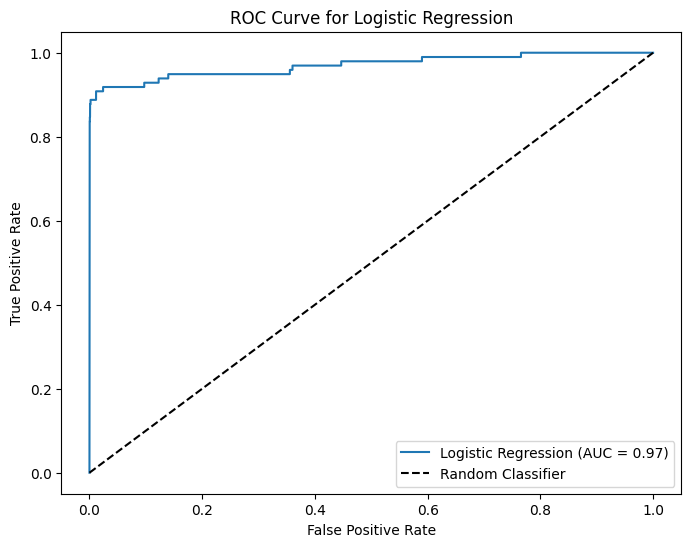

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and L1/L2 regularization
log_reg_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original (unbalanced) test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
display(pd.DataFrame(cm_log_reg, index=['Actual Normal', 'Actual Fraud'], columns=['Predicted Normal', 'Predicted Fraud']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

# Plot ROC curve
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_proba_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_log_reg):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

### 2. XGBoost Classifier

XGBoost (eXtreme Gradient Boosting) is a powerful and efficient implementation of gradient boosting, known for its high performance and speed. It's often a top choice for structured data problems, including fraud detection.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:00:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:


,Predicted Normal,Predicted Fraud
Actual Normal,56825,39
Actual Fraud,13,85



ROC-AUC Score: 0.9753


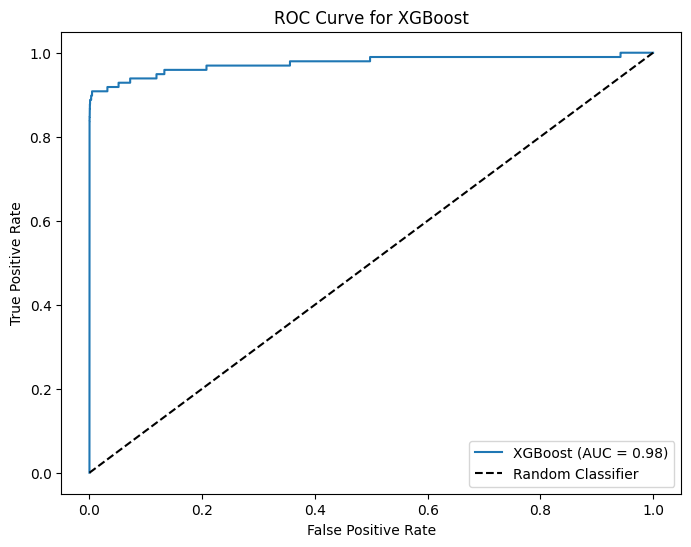

In [ ]:
import xgboost as xgb

# Initialize and train the XGBoost model
# Using 'use_label_encoder=False' and 'eval_metric' to suppress warnings
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original (unbalanced) test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
display(pd.DataFrame(cm_xgb, index=['Actual Normal', 'Actual Fraud'], columns=['Predicted Normal', 'Predicted Fraud']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Plot ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()

## Model Comparison and Explainability

After evaluating individual models, it's beneficial to compare their performance, especially considering the different strengths of Logistic Regression and XGBoost. Additionally, understanding *why* a model makes certain predictions can be crucial in FinTech, so we'll look into feature importance for the XGBoost model.

### Comparison of ROC Curves

Plotting both ROC curves on the same graph provides a clear visual comparison of how well each model distinguishes between classes across various thresholds.

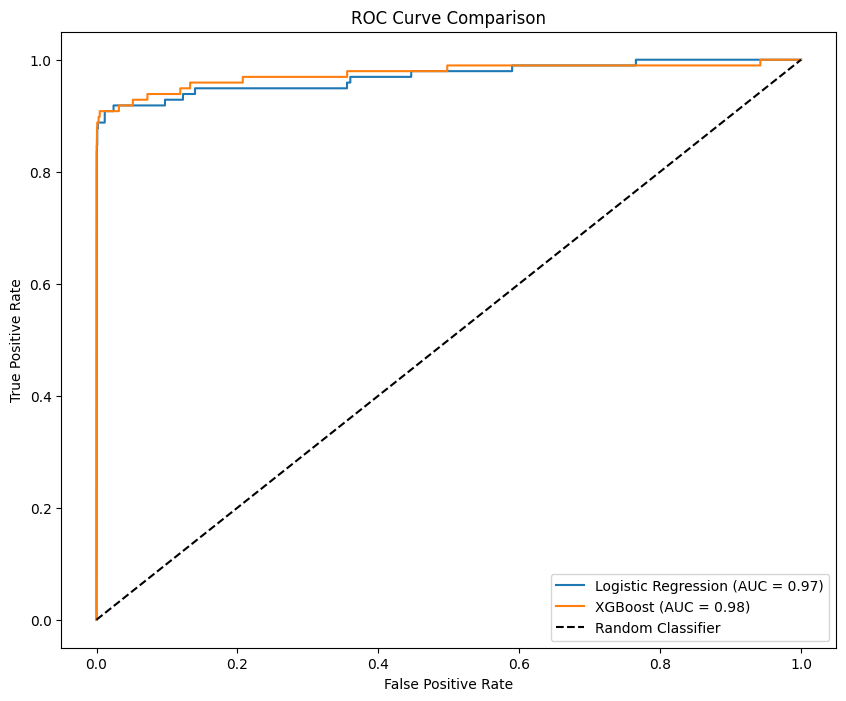

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_log_reg):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Feature Importance (XGBoost)

Understanding which features contribute most to the model's predictions can offer valuable insights into the nature of fraud and help in further feature engineering or business decisions. XGBoost provides a built-in way to extract feature importance.

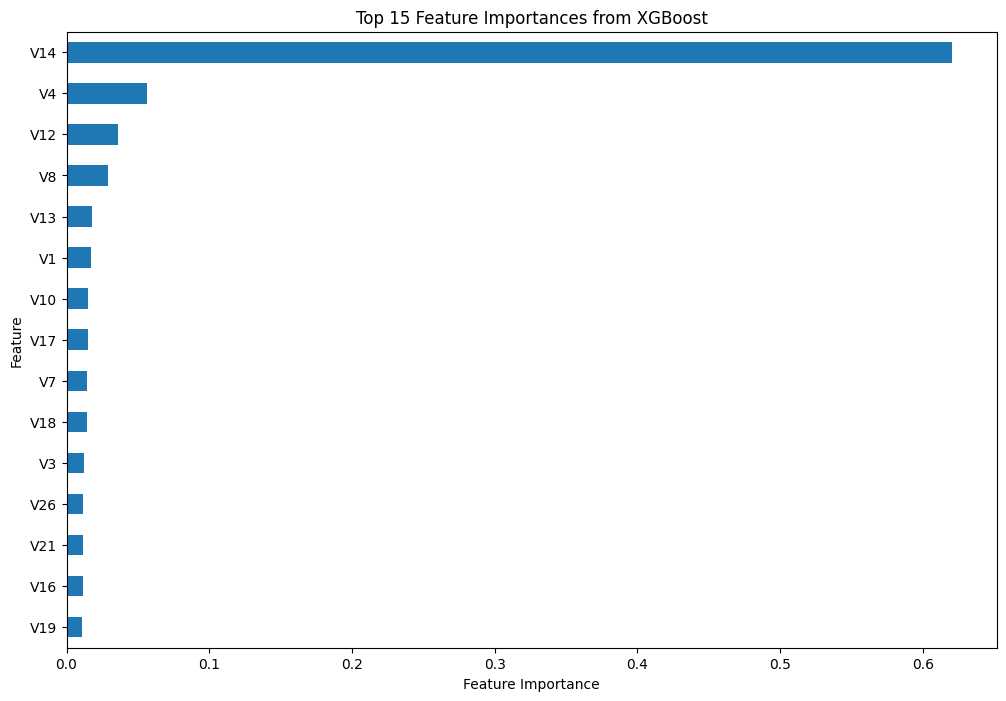

In [ ]:
# Get feature importances from the XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.Series(feature_importances, index=X.columns)

# Sort features by importance and plot the top N
top_n = 15 # You can adjust this number
plt.figure(figsize=(12, 8))
features_df.nlargest(top_n).plot(kind='barh')
plt.title(f'Top {top_n} Feature Importances from XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()